In [1]:
import pandas as pd
path = "dataMissingValue.csv"
df = pd.read_csv(path)
df

,Name,School Level,Blood Type,Age,Fav Fruit,Shoe Chart
0,A,High School,AB,15.0,apple,36.0
1,B,High School,NaN,17.0,banana,41.0
2,C,High School,NaN,NaN,watermelon,NaN
3,D,High School,NaN,16.0,NaN,38.0
4,E,Middle School,B,15.0,banana,37.0
5,F,Middle School,NaN,14.0,grapes,NaN
6,G,Middle School,O,NaN,mango,36.0
7,H,High School,A,16.0,papaya,39.0
8,I,High School,NaN,18.0,NaN,40.0
9,J,Middle School,NaN,NaN,avocado,35.0


In [2]:
df.isnull().sum()

Name            0
School Level    0
Blood Type      6
Age             3
Fav Fruit       2
Shoe Chart      2
dtype: int64

In [3]:
percent_missing = 100*df.isnull().mean()
percent_missing

Name             0.0
School Level     0.0
Blood Type      60.0
Age             30.0
Fav Fruit       20.0
Shoe Chart      20.0
dtype: float64

In [4]:
df.dropna(axis=0)

,Name,School Level,Blood Type,Age,Fav Fruit,Shoe Chart
0,A,High School,AB,15.0,apple,36.0
4,E,Middle School,B,15.0,banana,37.0
7,H,High School,A,16.0,papaya,39.0


In [5]:
df.dropna(axis=1)

,Name,School Level
0,A,High School
1,B,High School
2,C,High School
3,D,High School
4,E,Middle School
5,F,Middle School
6,G,Middle School
7,H,High School
8,I,High School
9,J,Middle School


In [6]:
df.dropna(thresh=5)

,Name,School Level,Blood Type,Age,Fav Fruit,Shoe Chart
0,A,High School,AB,15.0,apple,36.0
1,B,High School,NaN,17.0,banana,41.0
4,E,Middle School,B,15.0,banana,37.0
6,G,Middle School,O,NaN,mango,36.0
7,H,High School,A,16.0,papaya,39.0


In [7]:
df.dropna(subset=['Age'])

,Name,School Level,Blood Type,Age,Fav Fruit,Shoe Chart
0,A,High School,AB,15.0,apple,36.0
1,B,High School,NaN,17.0,banana,41.0
3,D,High School,NaN,16.0,NaN,38.0
4,E,Middle School,B,15.0,banana,37.0
5,F,Middle School,NaN,14.0,grapes,NaN
7,H,High School,A,16.0,papaya,39.0
8,I,High School,NaN,18.0,NaN,40.0


In [8]:
df_drop = df.drop(columns = 'Blood Type')
df_drop

,Name,School Level,Age,Fav Fruit,Shoe Chart
0,A,High School,15.0,apple,36.0
1,B,High School,17.0,banana,41.0
2,C,High School,NaN,watermelon,NaN
3,D,High School,16.0,NaN,38.0
4,E,Middle School,15.0,banana,37.0
5,F,Middle School,14.0,grapes,NaN
6,G,Middle School,NaN,mango,36.0
7,H,High School,16.0,papaya,39.0
8,I,High School,18.0,NaN,40.0
9,J,Middle School,NaN,avocado,35.0


In [9]:
df_filled = df_drop.copy()
df_filled['Age'] = df['Age'].fillna(df['Age'].mean())
df_filled

,Name,School Level,Age,Fav Fruit,Shoe Chart
0,A,High School,15.000000,apple,36.0
1,B,High School,17.000000,banana,41.0
2,C,High School,15.857143,watermelon,NaN
3,D,High School,16.000000,NaN,38.0
4,E,Middle School,15.000000,banana,37.0
5,F,Middle School,14.000000,grapes,NaN
6,G,Middle School,15.857143,mango,36.0
7,H,High School,16.000000,papaya,39.0
8,I,High School,18.000000,NaN,40.0
9,J,Middle School,15.857143,avocado,35.0


In [10]:
df_filled['Shoe Chart'] = df['Shoe Chart'].fillna(df['Shoe Chart'].median())
df_filled

,Name,School Level,Age,Fav Fruit,Shoe Chart
0,A,High School,15.000000,apple,36.0
1,B,High School,17.000000,banana,41.0
2,C,High School,15.857143,watermelon,37.5
3,D,High School,16.000000,NaN,38.0
4,E,Middle School,15.000000,banana,37.0
5,F,Middle School,14.000000,grapes,37.5
6,G,Middle School,15.857143,mango,36.0
7,H,High School,16.000000,papaya,39.0
8,I,High School,18.000000,NaN,40.0
9,J,Middle School,15.857143,avocado,35.0


In [11]:
df_filled['Fav Fruit'] = df['Fav Fruit'].fillna(df['Fav Fruit'].mode().iloc[0])
df_filled

,Name,School Level,Age,Fav Fruit,Shoe Chart
0,A,High School,15.000000,apple,36.0
1,B,High School,17.000000,banana,41.0
2,C,High School,15.857143,watermelon,37.5
3,D,High School,16.000000,banana,38.0
4,E,Middle School,15.000000,banana,37.0
5,F,Middle School,14.000000,grapes,37.5
6,G,Middle School,15.857143,mango,36.0
7,H,High School,16.000000,papaya,39.0
8,I,High School,18.000000,banana,40.0
9,J,Middle School,15.857143,avocado,35.0


In [12]:
df_filled2 = df_drop.copy()
df_filled2['Shoe Chart'] = df_filled2['Shoe Chart'].replace("", None).bfill()
df_filled2

,Name,School Level,Age,Fav Fruit,Shoe Chart
0,A,High School,15.0,apple,36.0
1,B,High School,17.0,banana,41.0
2,C,High School,NaN,watermelon,38.0
3,D,High School,16.0,NaN,38.0
4,E,Middle School,15.0,banana,37.0
5,F,Middle School,14.0,grapes,36.0
6,G,Middle School,NaN,mango,36.0
7,H,High School,16.0,papaya,39.0
8,I,High School,18.0,NaN,40.0
9,J,Middle School,NaN,avocado,35.0


In [13]:
df_filled2['Fav Fruit'] = df_filled2['Fav Fruit'].replace("", None).ffill()
df_filled2

,Name,School Level,Age,Fav Fruit,Shoe Chart
0,A,High School,15.0,apple,36.0
1,B,High School,17.0,banana,41.0
2,C,High School,NaN,watermelon,38.0
3,D,High School,16.0,watermelon,38.0
4,E,Middle School,15.0,banana,37.0
5,F,Middle School,14.0,grapes,36.0
6,G,Middle School,NaN,mango,36.0
7,H,High School,16.0,papaya,39.0
8,I,High School,18.0,papaya,40.0
9,J,Middle School,NaN,avocado,35.0


In [14]:
path = "weight-height_outlier.csv"
df2 = pd.read_csv(path)
df2

,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801
...,...,...,...
9995,Female,66.172652,136.777454
9996,Female,67.067155,170.867906
9997,Female,63.867992,128.475319
9998,Female,69.034243,163.852461


<Axes: ylabel='Height'>

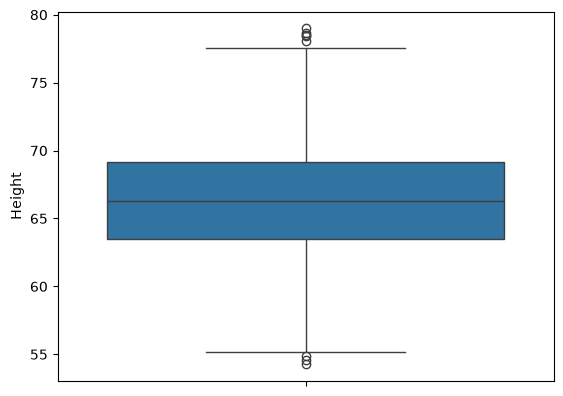

In [15]:
import seaborn as sns
sns.boxplot(df2['Height'])

<Axes: ylabel='Height'>

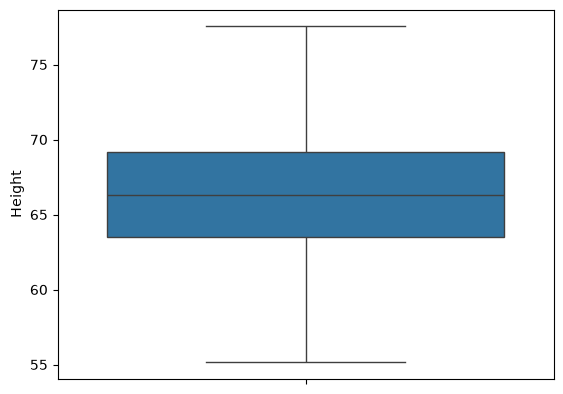

In [16]:
import numpy as np
# Identifikasi Q1 Q3
q1, q3 = np.percentile(df2['Height'], [25, 75])
# Hitung IQR
iqr = q3 - q1
# Cari Lower dan upper bounds
lower_bound = q1 - (1.5 * iqr)
upper_bound = q3 + (1.5 * iqr)
# Hapus outliers
clean_data = df2[(df2['Height'] >= lower_bound)
                 & (df2['Height'] <= upper_bound)]

sns.boxplot(clean_data['Height'])

<Axes: ylabel='Weight'>

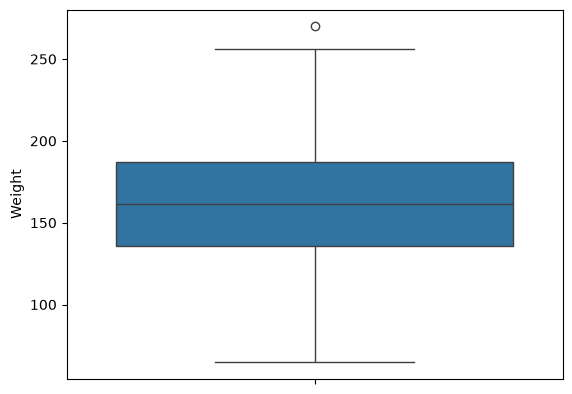

In [17]:
sns.boxplot(df2['Weight'])

<Axes: ylabel='Weight'>

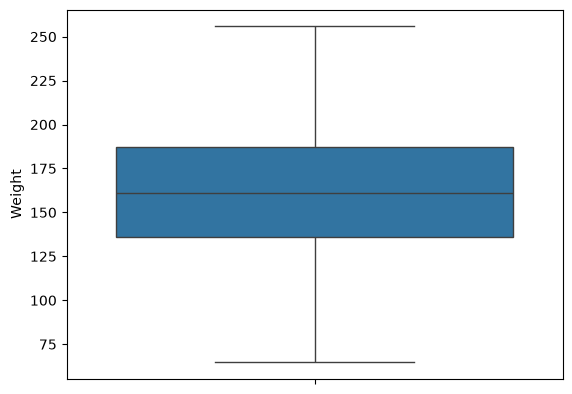

In [18]:
# Identifikasi Q1 Q3
q1, q3 = np.percentile(df2['Weight'], [25, 75])
# Hitung IQR
iqr = q3 - q1
# Cari Lower dan upper bounds
lower_bound = q1 - (1.5 * iqr)
upper_bound = q3 + (1.5 * iqr)
# Hapus outliers
clean_data = df2[(df2['Weight'] >= lower_bound)
                 & (df2['Weight'] <= upper_bound)]

sns.boxplot(clean_data['Weight'])

C:\Users\ASUS\AppData\Local\Temp\ipykernel_12552\860526150.py:15: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axs[i].boxplot(df2[col], vert=False)
C:\Users\ASUS\AppData\Local\Temp\ipykernel_12552\860526150.py:15: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axs[i].boxplot(df2[col], vert=False)


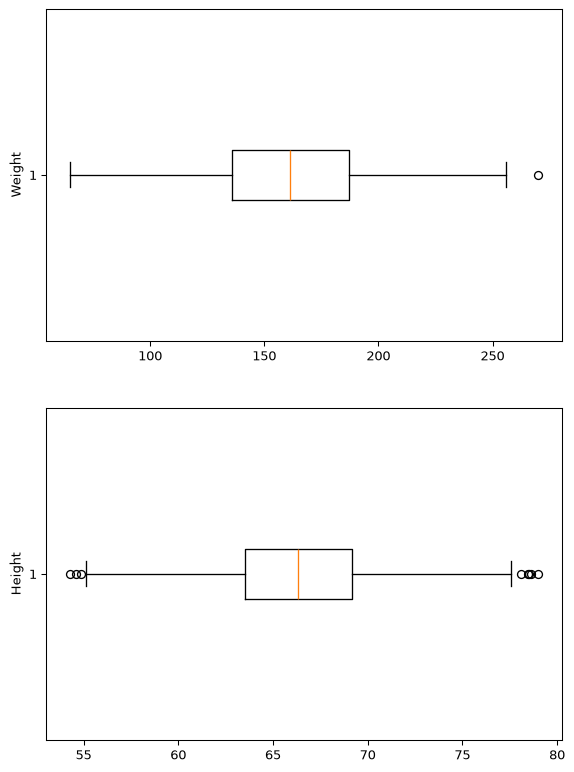

In [19]:
import matplotlib.pyplot as plt

# Membuat daftar kolom yang ingin dianalisis, yaitu "Weight" dan "Height".
columns_to_plot = ['Weight', 'Height']

# Memastikan kolom ada di dataset
columns_to_plot = [col for col in columns_to_plot if col in df2.columns]

fig, axs = plt.subplots(len(columns_to_plot), 1, dpi=95, figsize=(7, 5 * len(columns_to_plot)))

if len(columns_to_plot) == 1:
    axs = [axs]

for i, col in enumerate(columns_to_plot):
    axs[i].boxplot(df2[col], vert=False)
    axs[i].set_ylabel(col)

plt.show()

C:\Users\ASUS\AppData\Local\Temp\ipykernel_12552\777620602.py:23: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axs[i].boxplot(clean_data[col], vert=False)
C:\Users\ASUS\AppData\Local\Temp\ipykernel_12552\777620602.py:23: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axs[i].boxplot(clean_data[col], vert=False)


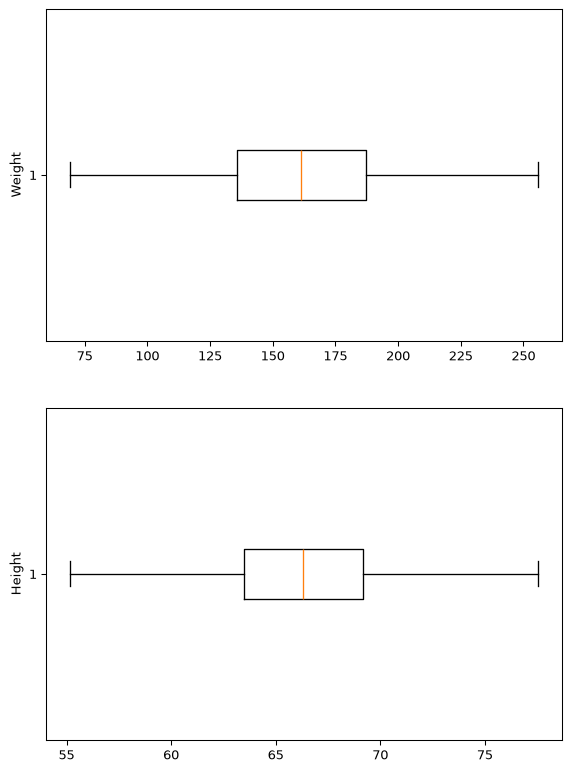

In [20]:
def remove_outliers_sequentially(df2, columns):
    df_cleaned = df2.copy()
    for col in columns:
        q1, q3 = np.percentile(df_cleaned[col], [25, 75])
        iqr = q3 - q1
        lower_bound = q1 - (1.5 * iqr)
        upper_bound = q3 + (1.5 * iqr)
        df_cleaned = df_cleaned[(df_cleaned[col] >= lower_bound) & (df_cleaned[col] <= upper_bound)]
    return df_cleaned


# Terapkan fungsi untuk menghapus outliers dari "Height" dan "Weight"
clean_data = remove_outliers_sequentially(df2, ['Height', 'Weight'])

# Plot boxplots setelah menghapus outliers
columns_to_plot = ['Weight', 'Height']
fig, axs = plt.subplots(len(columns_to_plot), 1, dpi=95, figsize=(7, 5 * len(columns_to_plot)))

if len(columns_to_plot) == 1:
    axs = [axs]

for i, col in enumerate(columns_to_plot):
    axs[i].boxplot(clean_data[col], vert=False)
    axs[i].set_ylabel(col)

plt.show()

In [21]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range=(0, 1))

# Memisahkan kolom numerik dan non-numerik
numeric_cols = clean_data.select_dtypes(include=[np.number]).columns  # Ambil kolom numerik
non_numeric_cols = clean_data.select_dtypes(exclude=[np.number]).columns  # Ambil kolom non-numerik

rescaled_numeric = scaler.fit_transform(clean_data[numeric_cols])
rescaled_numeric[:]

array([[0.83480376, 0.92524773],
       [0.6086688 , 0.49939825],
       [0.84654949, 0.76925146],
       ...,
       [0.38928431, 0.31834619],
       [0.61993463, 0.50764944],
       [0.30339752, 0.23901104]], shape=(9992, 2))

In [22]:
# Konversi kembali hasil scaling ke DataFrame
rescaled_df = pd.DataFrame(rescaled_numeric, columns=numeric_cols, index=clean_data.index)

# Gabungkan kembali dengan kolom non-numerik tanpa mengubah jumlah baris
final_df = pd.concat([clean_data[non_numeric_cols], rescaled_df], axis=1)

final_df

,Gender,Height,Weight
0,Male,0.834804,0.925248
1,Male,0.608669,0.499398
2,Male,0.846549,0.769251
3,Male,0.740332,0.808322
4,Male,0.657774,0.735053
...,...,...,...
9995,Female,0.492177,0.362771
9996,Female,0.532113,0.545189
9997,Female,0.389284,0.318346
9998,Female,0.619935,0.507649


In [4]:
# TUGAS 2: HANDLING MISSING VALUE DARI DATASET 'Titanic-Dataset.csv'

import pandas as pd
import numpy as np

print("TUGAS 2: HANDLING MISSING VALUES (Titanic-Dataset.csv)")

# 1. Membaca dataset Titanic
path_titanic = "Titanic-Dataset.csv"
df_titanic = pd.read_csv(path_titanic)

# 2. Cek missing value awal ringkas
print("[A] Missing Value Awal:")
print(df_titanic.isnull().sum()[df_titanic.isnull().sum() > 0])

percent_missing = 100 * df_titanic.isnull().mean()
print("\n[B] Persentase Missing Value (%):")
print(percent_missing[percent_missing > 0].round(2))

# 3. Penanganan Missing Value
df_clean_titanic = df_titanic.drop(columns=["Cabin"])
df_clean_titanic["Age"] = df_clean_titanic["Age"].fillna(
    df_clean_titanic["Age"].median()
)

mode_embarked = df_clean_titanic["Embarked"].mode().iloc[0]
df_clean_titanic["Embarked"] = df_clean_titanic["Embarked"].fillna(
    mode_embarked
)

# 4. Hasil akhir
print("\n[C] Missing Value Setelah Diatasi:")
print(df_clean_titanic.isnull().sum())

TUGAS 2: HANDLING MISSING VALUES (Titanic-Dataset.csv)
[A] Missing Value Awal:
Age         177
Cabin       687
Embarked      2
dtype: int64

[B] Persentase Missing Value (%):
Age         19.87
Cabin       77.10
Embarked     0.22
dtype: float64

[C] Missing Value Setelah Diatasi:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


TUGAS 3: HANDLING OUTLIERS (diabetes.csv)


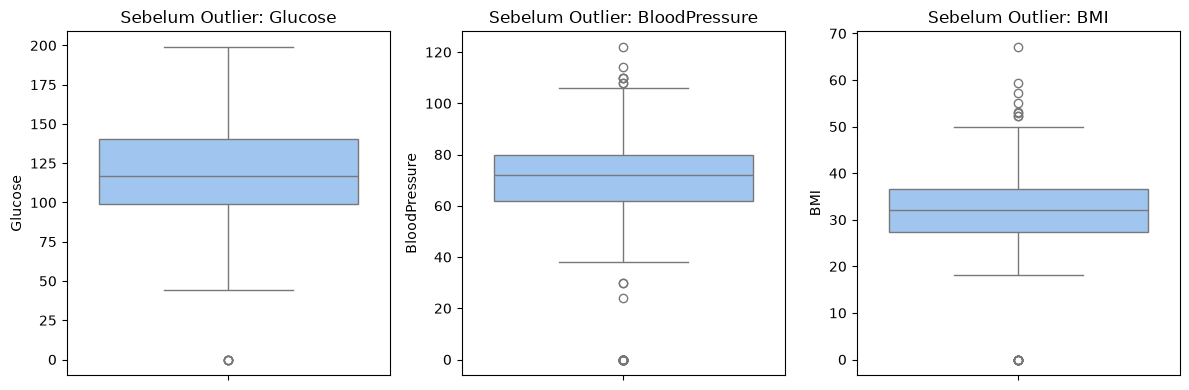

Kolom [Glucose]: Q1=99.00, Q3=140.25, IQR=41.25
  -> Batas Bawah=37.12, Batas Atas=202.12
Kolom [BloodPressure]: Q1=62.00, Q3=80.00, IQR=18.00
  -> Batas Bawah=35.00, Batas Atas=107.00
Kolom [BMI]: Q1=27.40, Q3=36.50, IQR=9.10
  -> Batas Bawah=13.75, Batas Atas=50.15

Jumlah data awal   : 768 baris
Jumlah data bersih : 709 baris
Outlier terbuang   : 59 baris


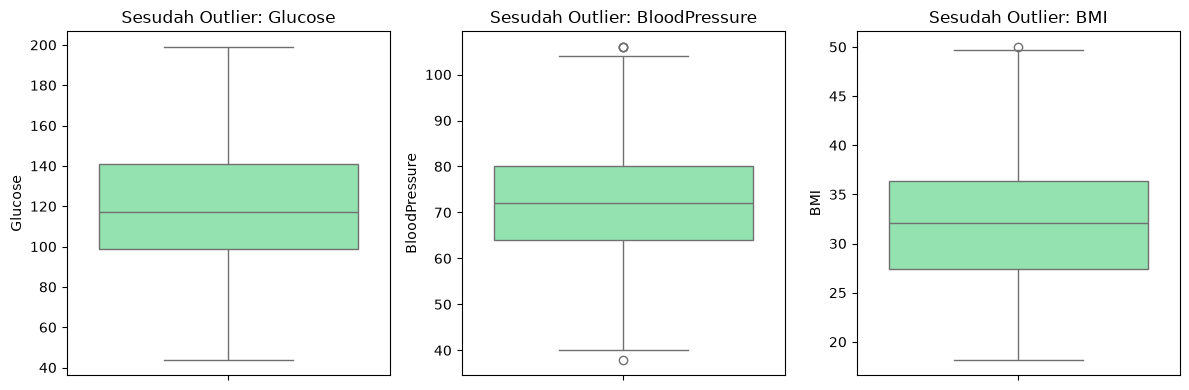


[D] Contoh 5 Data Diabetes Setelah Pembersihan & Min-Max Scaling:
    Glucose  BloodPressure       BMI
0  0.670968       0.500000  0.484277
1  0.264516       0.411765  0.264151
2  0.896774       0.382353  0.160377
3  0.290323       0.411765  0.311321
4  0.600000       0.029412  0.783019


In [5]:
# TUGAS 3: HANDLING OUTLIERS DARI DATASET 'diabetes.csv'
# 3 Kolom yang dipilih: 'Glucose', 'BloodPressure', 'BMI'
import seaborn as sns
import matplotlib.pyplot as plt

print("TUGAS 3: HANDLING OUTLIERS (diabetes.csv)")

# 1. Membaca dataset Diabetes
path_diabetes = "diabetes.csv"
df_diabetes = pd.read_csv(path_diabetes)

# 2. Memilih 3 kolom untuk deteksi outlier
columns_to_analyze = ['Glucose', 'BloodPressure', 'BMI']

# 3. Visualisasi Boxplot SEBELUM Penanganan Outlier
plt.figure(figsize=(12, 4))
for i, col in enumerate(columns_to_analyze, 1):
    plt.subplot(1, 3, i)
    sns.boxplot(y=df_diabetes[col], color='#93c5fd')
    plt.title(f'Sebelum Outlier: {col}')
    plt.ylabel(col)
plt.tight_layout()
plt.show()

# 4. Fungsi Menghapus Outlier secara Berurutan (Metode IQR sesuai Modul)
def remove_outliers_sequentially(df, columns):
    df_cleaned = df.copy()
    for col in columns:
        # Hitung Q1 (25%) dan Q3 (75%)
        q1, q3 = np.percentile(df_cleaned[col].dropna(), [25, 75])
        iqr = q3 - q1
        
        lower_bound = q1 - (1.5 * iqr)
        upper_bound = q3 + (1.5 * iqr)
        
        print(f"Kolom [{col}]: Q1={q1:.2f}, Q3={q3:.2f}, IQR={iqr:.2f}")
        print(f"  -> Batas Bawah={lower_bound:.2f}, Batas Atas={upper_bound:.2f}")
        
        # Filter baris yang berada dalam batas toleransi IQR
        df_cleaned = df_cleaned[(df_cleaned[col] >= lower_bound) & (df_cleaned[col] <= upper_bound)]
    return df_cleaned

# 5. Eksekusi penghapusan outlier
clean_diabetes = remove_outliers_sequentially(df_diabetes, columns_to_analyze)

print(f"\nJumlah data awal   : {len(df_diabetes)} baris")
print(f"Jumlah data bersih : {len(clean_diabetes)} baris")
print(f"Outlier terbuang   : {len(df_diabetes) - len(clean_diabetes)} baris")

# 6. Visualisasi Boxplot SESUDAH Penanganan Outlier
plt.figure(figsize=(12, 4))
for i, col in enumerate(columns_to_analyze, 1):
    plt.subplot(1, 3, i)
    sns.boxplot(y=clean_diabetes[col], color='#86efac')
    plt.title(f'Sesudah Outlier: {col}')
    plt.ylabel(col)
plt.tight_layout()
plt.show()

# 7. Normalisasi Data (MinMaxScaler) Sesuai Step Modul Terakhir
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range=(0, 1))

numeric_cols = clean_diabetes.select_dtypes(include=[np.number]).columns
rescaled_numeric = scaler.fit_transform(clean_diabetes[numeric_cols])

final_diabetes_df = pd.DataFrame(rescaled_numeric, columns=numeric_cols, index=clean_diabetes.index)
print("\n[D] Contoh 5 Data Diabetes Setelah Pembersihan & Min-Max Scaling:")
print(final_diabetes_df[columns_to_analyze].head())